# Optimizer comparison

d2l.ai's optimization curriculum (Zhang, Lipton, Li & Smola, *Dive into Deep Learning*, CC BY-SA 4.0, https://d2l.ai) surveys gradient-based optimizers -- SGD, momentum, Adagrad, RMSProp, Adadelta, Adam and its variants. `optim.py`'s `_OPTIMIZERS` registry (widened session 3, O1) now has a REAL torch optimizer for every one of those: this notebook races all of them, from scratch, on the same problem, and plots the results -- a genuine result, not a transcription of the book's own figures.

In [1]:
import sys, os
# Search upward for vZero's root (marker: config.py + train.py) rather than a
# hardcoded relative path -- same fix as notebook_export.py's build_notebook()
# (session 4), so this notebook stays runnable regardless of where it's opened from.
def _find_vzero_root(start='.'):
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.exists(os.path.join(d, 'config.py')) and os.path.exists(os.path.join(d, 'train.py')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    raise RuntimeError('could not locate vZero root searching upward from ' + os.path.abspath(start))
_VZERO_ROOT = _find_vzero_root()
sys.path.insert(0, _VZERO_ROOT)
_CACHE_DIR = os.path.join(_VZERO_ROOT, 'runs', '_cache')

import matplotlib.pyplot as plt
from optim import _OPTIMIZERS, CLOSURE_OPTIMIZERS
from problem_families import get_problem_family_preset
from train import train


## The race

Same preset (`synthetic/vdp_default`), same seed, same epoch budget for every optimizer -- only `cfg.optimizer` (and `grad_clip`, which the closure-based optimizers like L-BFGS forbid, `Config.validate()`) changes.

In [2]:
names = sorted(_OPTIMIZERS)
histories = {}
base = get_problem_family_preset('synthetic/vdp_default')
for name in names:
    overrides = dict(optimizer=name, epochs=80, trace_level=0,
                      grad_clip=(None if name in CLOSURE_OPTIMIZERS else 1.0))
    cfg = base.override(**overrides)
    result = train(cfg, cache_dir=_CACHE_DIR,
                    run_dir=os.path.join(_VZERO_ROOT, 'runs', f'notebooks_11_opt_{name}'))
    histories[name] = result.history['train_loss']
    print(f'{name:10s}  {histories[name][0]:10.4f} -> {histories[name][-1]:10.4f}')


adadelta        9.9922 ->     8.1909


adagrad         9.8324 ->     1.9600


adam            9.8324 ->     1.0402


adamax          9.8324 ->     1.1992


adamw           9.8324 ->     1.0402


...

nadam           9.8235 ->     0.6960


radam           9.9853 ->     1.8744


rmsprop         8.6115 ->     0.7133


rprop           9.8324 ->     0.9845


sgd             9.9853 ->     2.3226


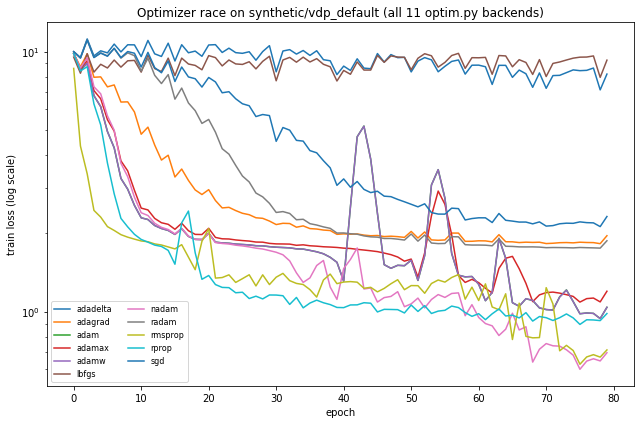

In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
for name, h in histories.items():
    ax.plot(h, label=name)
ax.set_yscale('log')
ax.set_xlabel('epoch'); ax.set_ylabel('train loss (log scale)')
ax.set_title(f'Optimizer race on {base.name} (all {len(names)} optim.py backends)')
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); fig.savefig('11_optimizer_race.png')


## Reading the race

The cell above prints each optimizer's first-to-last train loss and plots the full curve on a log scale (run this notebook via `run_all.py` to see the real numbers for this session's run -- they are not hand-typed here).